# Cross-validation: evaluating estimator performance

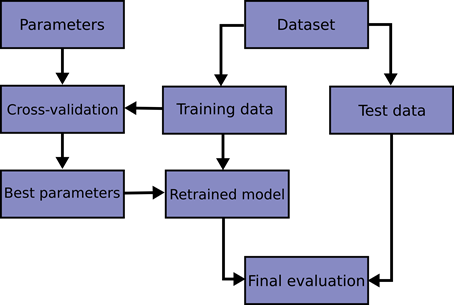

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

In [5]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)

### Holdout method

In [7]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5)
print(scores, '\n')
print('평균: ', scores.mean())

[0.96666667 0.96666667 0.93333333 0.96666667 1.        ] 

평균:  0.9666666666666668


In [13]:
scores = pd.DataFrame(cross_validate(model, X, y, cv = 5))
print(scores, '\n')
print('평균: ', scores.test_score.mean())

   fit_time  score_time  test_score
0  0.001652    0.004737    0.966667
1  0.000000    0.000000    0.966667
2  0.000000    0.000000    0.933333
3  0.000000    0.000000    0.966667
4  0.015632    0.003003    1.000000 

평균:  0.9666666666666668


 ### K Folder

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score , cross_validate
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.datasets import load_iris
import numpy as np

In [15]:
kfold = KFold(n_splits=5)

In [17]:
iris = load_iris()
feature = iris.data
label = iris.target

In [19]:
cv_accuracy = []
n_iter =0
dt_clf = DecisionTreeClassifier(random_state=1)

In [21]:
feature.shape

(150, 4)

In [41]:
# feature

In [23]:
n_iter =0
for train_index, test_index in kfold.split(feature):  
    x_train, x_test = feature[train_index], feature[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    
    accuracy = np.round(accuracy_score(y_test, pred), 4) 
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    
    print('\n#{0} 교차 검증 정확도 : {1},  학습 데이터 크기 : {2},  검증 데이터 크기 : {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))    


#1 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 120,  검증 데이터 크기 : 30
#1 검증 세트 인덱스 : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 120,  검증 데이터 크기 : 30
#2 검증 세트 인덱스 : [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도 : 0.9,  학습 데이터 크기 : 120,  검증 데이터 크기 : 30
#3 검증 세트 인덱스 : [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도 : 0.9333,  학습 데이터 크기 : 120,  검증 데이터 크기 : 30
#4 검증 세트 인덱스 : [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도 : 0.7333,  학습 데이터 크기 : 120,  검증 데이터 크기 : 30
#5 검증 세트 인덱스 : [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.91332


### Stratified k-fold cross validation

In [25]:
from sklearn.model_selection import StratifiedKFold

In [99]:
S_kfold = StratifiedKFold(n_splits=5)
cv_accuracy = []
n_iter =0

for train_index, test_index in S_kfold.split(feature, label):  
    x_train, x_test = feature[train_index], feature[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    
    accuracy = np.round(accuracy_score(y_test, pred), 4) 
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    
    print('\n#{0} 교차 검증 정확도 : {1},  학습 데이터 크기 : {2},  테스트 데이터 크기 : {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도 : 0.9667,  학습 데이터 크기 : 120,  테스트 데이터 크기 : 30
#1 검증 세트 인덱스 : [  0   1   2   3   4   5   6   7   8   9  50  51  52  53  54  55  56  57
  58  59 100 101 102 103 104 105 106 107 108 109]

#2 교차 검증 정확도 : 0.9667,  학습 데이터 크기 : 120,  테스트 데이터 크기 : 30
#2 검증 세트 인덱스 : [ 10  11  12  13  14  15  16  17  18  19  60  61  62  63  64  65  66  67
  68  69 110 111 112 113 114 115 116 117 118 119]

#3 교차 검증 정확도 : 0.9,  학습 데이터 크기 : 120,  테스트 데이터 크기 : 30
#3 검증 세트 인덱스 : [ 20  21  22  23  24  25  26  27  28  29  70  71  72  73  74  75  76  77
  78  79 120 121 122 123 124 125 126 127 128 129]

#4 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 120,  테스트 데이터 크기 : 30
#4 검증 세트 인덱스 : [ 30  31  32  33  34  35  36  37  38  39  80  81  82  83  84  85  86  87
  88  89 130 131 132 133 134 135 136 137 138 139]

#5 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 120,  테스트 데이터 크기 : 30
#5 검증 세트 인덱스 : [ 40  41  42  43  44  45  46  47  48  49  90  91  92  93  94  95  96  97
  98  99 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.96668


### LOOCV (Leave-one-out Cross-validation)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

In [44]:
loocv = LeaveOneOut()
cv_accuracy = []
n_iter =0

for train_index, test_index in loocv.split(feature, label):  
    x_train, x_test = feature[train_index], feature[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    
    accuracy = np.round(accuracy_score(y_test, pred), 4) 
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    
    print('\n#{0} 교차 검증 정확도 : {1},  학습 데이터 크기 : {2},  테스트 데이터 크기 : {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#1 검증 세트 인덱스 : [0]

#2 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#2 검증 세트 인덱스 : [1]

#3 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#3 검증 세트 인덱스 : [2]

#4 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#4 검증 세트 인덱스 : [3]

#5 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#5 검증 세트 인덱스 : [4]

#6 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#6 검증 세트 인덱스 : [5]

#7 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#7 검증 세트 인덱스 : [6]

#8 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#8 검증 세트 인덱스 : [7]

#9 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#9 검증 세트 인덱스 : [8]

#10 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#10 검증 세트 인덱스 : [9]

#11 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#11 검증 세트 인덱스 : [10]

#12 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#12 검증 세트 인덱스 : [11]

#13 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 149,  테스트 데이터 크기 : 1
#13 검증 세트 인덱스 : [12]

#14 교차 검증 정확도 : 1.0,  학습 데

### LPOCV (Leave-p-out Cross-validation)

In [26]:
import numpy as np
from sklearn.model_selection import LeavePOut
# X = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
# y = np.array([1, 2, 3, 4])
# lpo = LeavePOut(2)
# lpo.get_n_splits(X)
# print(lpo)
# for i, (train_index, test_index) in enumerate(lpo.split(X)):
#     print(f"Fold {i}:")
#     print(f"  Train: index={train_index}")
#     print(f"  Test:  index={test_index}")

In [100]:
lpocv = LeavePOut(2)
cv_accuracy = []
n_iter =0

for train_index, test_index in lpocv.split(feature, label):  
    x_train, x_test = feature[train_index], feature[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    
    accuracy = np.round(accuracy_score(y_test, pred), 4) 
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    
    print('\n#{0} 교차 검증 정확도 : {1},  학습 데이터 크기 : {2},  테스트 데이터 크기 : {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1 검증 세트 인덱스 : [0 1]

#2 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#2 검증 세트 인덱스 : [0 2]

#3 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#3 검증 세트 인덱스 : [0 3]

#4 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#4 검증 세트 인덱스 : [0 4]

#5 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#5 검증 세트 인덱스 : [0 5]

#6 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#6 검증 세트 인덱스 : [0 6]

#7 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#7 검증 세트 인덱스 : [0 7]

#8 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#8 검증 세트 인덱스 : [0 8]

#9 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9 검증 세트 인덱스 : [0 9]

#10 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10 검증 세트 인덱스 : [ 0 10]

#11 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#11 검증 세트 인덱스 : [ 0 11]

#12 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#12 검증 세트 인덱스 : [ 0 12]

#13 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#13 검증 세트 인덱스 : [ 0 


#296 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#296 검증 세트 인덱스 : [  1 148]

#297 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#297 검증 세트 인덱스 : [  1 149]

#298 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#298 검증 세트 인덱스 : [2 3]

#299 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#299 검증 세트 인덱스 : [2 4]

#300 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#300 검증 세트 인덱스 : [2 5]

#301 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#301 검증 세트 인덱스 : [2 6]

#302 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#302 검증 세트 인덱스 : [2 7]

#303 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#303 검증 세트 인덱스 : [2 8]

#304 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#304 검증 세트 인덱스 : [2 9]

#305 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#305 검증 세트 인덱스 : [ 2 10]

#306 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#306 검증 세트 인덱스 : [ 2 11]

#307 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#307 검증 세트 인덱스 : [ 2 12]

#308 교차 검증 정확도 : 1.0,  학습


#588 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#588 검증 세트 인덱스 : [  3 147]

#589 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#589 검증 세트 인덱스 : [  3 148]

#590 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#590 검증 세트 인덱스 : [  3 149]

#591 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#591 검증 세트 인덱스 : [4 5]

#592 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#592 검증 세트 인덱스 : [4 6]

#593 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#593 검증 세트 인덱스 : [4 7]

#594 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#594 검증 세트 인덱스 : [4 8]

#595 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#595 검증 세트 인덱스 : [4 9]

#596 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#596 검증 세트 인덱스 : [ 4 10]

#597 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#597 검증 세트 인덱스 : [ 4 11]

#598 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#598 검증 세트 인덱스 : [ 4 12]

#599 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#599 검증 세트 인덱스 : [ 4 13]

#600 교차 검증 정확도 : 1.


#884 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#884 검증 세트 인덱스 : [ 6 11]

#885 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#885 검증 세트 인덱스 : [ 6 12]

#886 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#886 검증 세트 인덱스 : [ 6 13]

#887 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#887 검증 세트 인덱스 : [ 6 14]

#888 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#888 검증 세트 인덱스 : [ 6 15]

#889 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#889 검증 세트 인덱스 : [ 6 16]

#890 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#890 검증 세트 인덱스 : [ 6 17]

#891 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#891 검증 세트 인덱스 : [ 6 18]

#892 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#892 검증 세트 인덱스 : [ 6 19]

#893 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#893 검증 세트 인덱스 : [ 6 20]

#894 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#894 검증 세트 인덱스 : [ 6 21]

#895 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#895 검증 세트 인덱스 : [ 6 22]

#896 교차 검증 정확도 


#1205 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1205 검증 세트 인덱스 : [ 8 49]

#1206 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1206 검증 세트 인덱스 : [ 8 50]

#1207 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1207 검증 세트 인덱스 : [ 8 51]

#1208 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1208 검증 세트 인덱스 : [ 8 52]

#1209 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1209 검증 세트 인덱스 : [ 8 53]

#1210 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1210 검증 세트 인덱스 : [ 8 54]

#1211 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1211 검증 세트 인덱스 : [ 8 55]

#1212 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1212 검증 세트 인덱스 : [ 8 56]

#1213 교차 검증 정확도 : 0.5,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1213 검증 세트 인덱스 : [ 8 57]

#1214 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1214 검증 세트 인덱스 : [ 8 58]

#1215 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1215 검증 세트 인덱스 : [ 8 59]

#1216 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#1216 검증 세트 인덱스 : 

...


#9701 교차 검증 정확도 : 0.5,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9701 검증 세트 인덱스 : [ 95 106]

#9702 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9702 검증 세트 인덱스 : [ 95 107]

#9703 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9703 검증 세트 인덱스 : [ 95 108]

#9704 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9704 검증 세트 인덱스 : [ 95 109]

#9705 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9705 검증 세트 인덱스 : [ 95 110]

#9706 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9706 검증 세트 인덱스 : [ 95 111]

#9707 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9707 검증 세트 인덱스 : [ 95 112]

#9708 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9708 검증 세트 인덱스 : [ 95 113]

#9709 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9709 검증 세트 인덱스 : [ 95 114]

#9710 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9710 검증 세트 인덱스 : [ 95 115]

#9711 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#9711 검증 세트 인덱스 : [ 95 116]

#9712 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 


#10001 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10001 검증 세트 인덱스 : [101 103]

#10002 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10002 검증 세트 인덱스 : [101 104]

#10003 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10003 검증 세트 인덱스 : [101 105]

#10004 교차 검증 정확도 : 0.5,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10004 검증 세트 인덱스 : [101 106]

#10005 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10005 검증 세트 인덱스 : [101 107]

#10006 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10006 검증 세트 인덱스 : [101 108]

#10007 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10007 검증 세트 인덱스 : [101 109]

#10008 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10008 검증 세트 인덱스 : [101 110]

#10009 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10009 검증 세트 인덱스 : [101 111]

#10010 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10010 검증 세트 인덱스 : [101 112]

#10011 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10011 검증 세트 인덱스 : [101 113]

#10012 교차 검증 정확도 : 1.0,  학습 데이터


#10314 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10314 검증 세트 인덱스 : [107 149]

#10315 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10315 검증 세트 인덱스 : [108 109]

#10316 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10316 검증 세트 인덱스 : [108 110]

#10317 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10317 검증 세트 인덱스 : [108 111]

#10318 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10318 검증 세트 인덱스 : [108 112]

#10319 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10319 검증 세트 인덱스 : [108 113]

#10320 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10320 검증 세트 인덱스 : [108 114]

#10321 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10321 검증 세트 인덱스 : [108 115]

#10322 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10322 검증 세트 인덱스 : [108 116]

#10323 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10323 검증 세트 인덱스 : [108 117]

#10324 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10324 검증 세트 인덱스 : [108 118]

#10325 교차 검증 정확도 : 0.5,  학습 데이터


#10620 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10620 검증 세트 인덱스 : [116 122]

#10621 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10621 검증 세트 인덱스 : [116 123]

#10622 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10622 검증 세트 인덱스 : [116 124]

#10623 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10623 검증 세트 인덱스 : [116 125]

#10624 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10624 검증 세트 인덱스 : [116 126]

#10625 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10625 검증 세트 인덱스 : [116 127]

#10626 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10626 검증 세트 인덱스 : [116 128]

#10627 교차 검증 정확도 : 0.5,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10627 검증 세트 인덱스 : [116 129]

#10628 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10628 검증 세트 인덱스 : [116 130]

#10629 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10629 검증 세트 인덱스 : [116 131]

#10630 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10630 검증 세트 인덱스 : [116 132]

#10631 교차 검증 정확도 : 0.5,  학습 데이터


#10936 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10936 검증 세트 인덱스 : [127 141]

#10937 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10937 검증 세트 인덱스 : [127 142]

#10938 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10938 검증 세트 인덱스 : [127 143]

#10939 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10939 검증 세트 인덱스 : [127 144]

#10940 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10940 검증 세트 인덱스 : [127 145]

#10941 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10941 검증 세트 인덱스 : [127 146]

#10942 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10942 검증 세트 인덱스 : [127 147]

#10943 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10943 검증 세트 인덱스 : [127 148]

#10944 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10944 검증 세트 인덱스 : [127 149]

#10945 교차 검증 정확도 : 0.5,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10945 검증 세트 인덱스 : [128 129]

#10946 교차 검증 정확도 : 1.0,  학습 데이터 크기 : 148,  테스트 데이터 크기 : 2
#10946 검증 세트 인덱스 : [128 130]

#10947 교차 검증 정확도 : 1.0,  학습 데이터

## K-fold

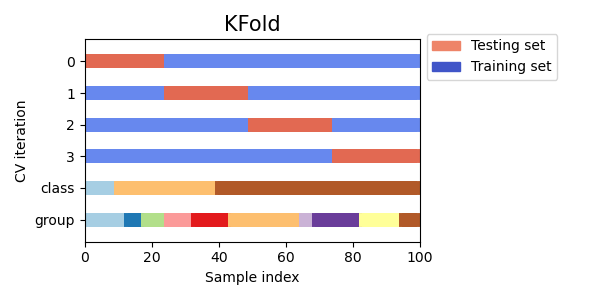

## Repeated K-Fold

In [59]:
import numpy as np
from sklearn.model_selection import RepeatedKFold

In [102]:
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]])
random_state = 12883823
rkf = RepeatedKFold(n_splits=2, n_repeats=2, random_state=random_state)
for train, test in rkf.split(X):
    print("%s %s" % (train, test))

[2 3] [0 1]
[0 1] [2 3]
[0 2] [1 3]
[1 3] [0 2]


## Leave One Out (LOO)

In [103]:
from sklearn.model_selection import LeaveOneOut

X = [1, 2, 3, 4]
loo = LeaveOneOut()
for train, test in loo.split(X):
    print("%s %s" % (train, test))

[1 2 3] [0]
[0 2 3] [1]
[0 1 3] [2]
[0 1 2] [3]


## Leave P Out (LPO)

In [104]:
from sklearn.model_selection import LeavePOut

X = np.ones(4)
lpo = LeavePOut(p=2)
for train, test in lpo.split(X):
    print("%s %s" % (train, test))

[2 3] [0 1]
[1 3] [0 2]
[1 2] [0 3]
[0 3] [1 2]
[0 2] [1 3]
[0 1] [2 3]


## 임의 분할 교차 검증 (Shuffle Split)

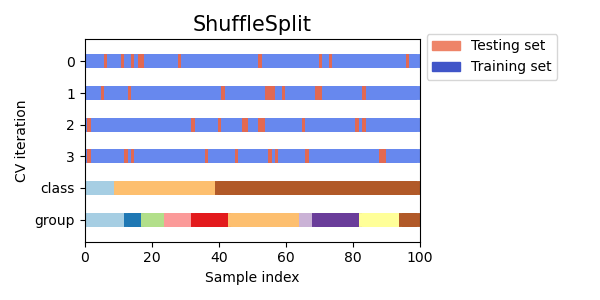

In [105]:
from sklearn.model_selection import ShuffleSplit

In [106]:
X = np.arange(10)
ss = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)
for train_index, test_index in ss.split(X):
    print("%s %s" % (train_index, test_index))

[9 1 6 7 3 0 5] [2 8 4]
[2 9 8 0 6 7 4] [3 5 1]
[4 5 1 0 6 9 7] [2 3 8]
[2 7 5 8 0 3 4] [6 1 9]
[4 1 0 6 8 9 3] [5 2 7]


## Stratified k-fold

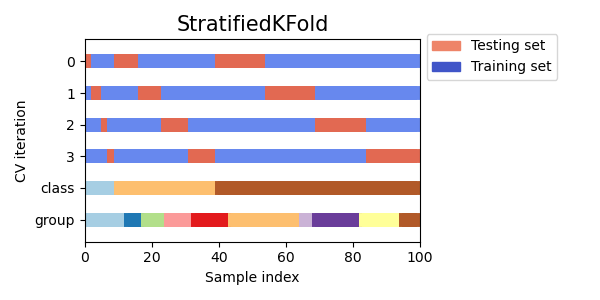

In [107]:
from sklearn.model_selection import StratifiedKFold, KFold
import numpy as np

In [108]:
X, y = np.ones((50, 1)), np.hstack(([0] * 45, [1] * 5))
skf = StratifiedKFold(n_splits=3)

for train, test in skf.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y[train]), np.bincount(y[test])))
kf = KFold(n_splits=3)

for train, test in kf.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y[train]), np.bincount(y[test])))

train -  [30  3]   |   test -  [15  2]
train -  [30  3]   |   test -  [15  2]
train -  [30  4]   |   test -  [15  1]
train -  [28  5]   |   test -  [17]
train -  [28  5]   |   test -  [17]
train -  [34]   |   test -  [11  5]


## Stratified Shuffle Split

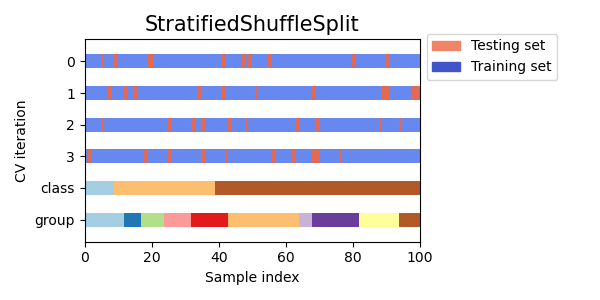

## Group k-fold
환자 의료 데이터와 각 환자의 샘플 채취 데이터 같이 개별 그룹에 따라 데이터가 달라지는 경우가 있을 수 있다. 이때, 특정 그룹 집합에 대해 훈련된 모델이 다른 그룹에 잘 일반화되는지 알고 싶다면 이를 측정하려면 validation fold의 모든 샘플이 짝을 이루는 train fold에서 오지 않았는지 확인해야 한다.

In [79]:
from sklearn.model_selection import GroupKFold

In [80]:
X = np.array([0.1, 0.2, 2.2, 2.4, 2.3, 4.55, 5.8, 8.8, 9, 10])
y = np.array(["a", "b", "b", "b", "c", "c", "c", "d", "d", "d"])
groups = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 3])

gkf = GroupKFold(n_splits=3)
gkf.get_n_splits(X, y, groups)
for train_index, test_index in gkf.split(X, y, groups=groups):
    print("%s %s" % (train, test))
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(X_train, X_test, y_train, y_test)

[3 4 5 6 7 8 9] [0 1 2]
[0.1  0.2  2.2  2.4  2.3  4.55] [ 5.8  8.8  9.  10. ] ['a' 'b' 'b' 'b' 'c' 'c'] ['c' 'd' 'd' 'd']
[3 4 5 6 7 8 9] [0 1 2]
[ 0.1  0.2  2.2  5.8  8.8  9.  10. ] [2.4  2.3  4.55] ['a' 'b' 'b' 'c' 'd' 'd' 'd'] ['b' 'c' 'c']
[3 4 5 6 7 8 9] [0 1 2]
[ 2.4   2.3   4.55  5.8   8.8   9.   10.  ] [0.1 0.2 2.2] ['b' 'c' 'c' 'c' 'd' 'd' 'd'] ['a' 'b' 'b']


##  StratifiedGroupKFold

In [86]:
from sklearn.model_selection import StratifiedGroupKFold
X = list(range(18))
y = [1] * 6 + [0] * 12
groups = [1, 2, 3, 3, 4, 4, 1, 1, 2, 2, 3, 4, 5, 5, 5, 6, 6, 6]
sgkf = StratifiedGroupKFold(n_splits=3)
for train, test in sgkf.split(X, y, groups=groups):
    print("%s %s" % (train, test))

[ 0  2  3  4  5  6  7 10 11 15 16 17] [ 1  8  9 12 13 14]
[ 0  1  4  5  6  7  8  9 11 12 13 14] [ 2  3 10 15 16 17]
[ 1  2  3  8  9 10 12 13 14 15 16 17] [ 0  4  5  6  7 11]


## Leave One Group Out

In [90]:
from sklearn.model_selection import LeaveOneGroupOut

In [91]:
X = [1, 5, 10, 50, 60, 70, 80]
y = [0, 1, 1, 2, 2, 2, 2]
groups = [1, 1, 2, 2, 3, 3, 3]
logo = LeaveOneGroupOut()
for train, test in logo.split(X, y, groups=groups):
    print("%s %s" % (train, test))

[2 3 4 5 6] [0 1]
[0 1 4 5 6] [2 3]
[0 1 2 3] [4 5 6]


## Leave P Groups Out

In [93]:
from sklearn.model_selection import LeavePGroupsOut

In [94]:
X = np.arange(6)
y = [1, 1, 1, 2, 2, 2]
groups = [1, 1, 2, 2, 3, 3]
lpgo = LeavePGroupsOut(n_groups=2)
for train, test in lpgo.split(X, y, groups=groups):
    print("%s %s" % (train, test))

[4 5] [0 1 2 3]
[2 3] [0 1 4 5]
[0 1] [2 3 4 5]


## Group Shuffle Split

In [95]:
from sklearn.model_selection import GroupShuffleSplit

In [96]:
X = [0.1, 0.2, 2.2, 2.4, 2.3, 4.55, 5.8, 0.001]
y = ["a", "b", "b", "b", "c", "c", "c", "a"]
groups = [1, 1, 2, 2, 3, 3, 4, 4]
gss = GroupShuffleSplit(n_splits=4, test_size=0.5, random_state=0)
for train, test in gss.split(X, y, groups=groups):
    print("%s %s" % (train, test))

[0 1 2 3] [4 5 6 7]
[2 3 6 7] [0 1 4 5]
[2 3 4 5] [0 1 6 7]
[4 5 6 7] [0 1 2 3]
